<a href="https://colab.research.google.com/github/inalaabhishek/AMAZON-PRIME-EDA/blob/main/Amazon_Prime_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Import libraries needed for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the two dataset files
titles = pd.read_csv("titles.csv")
credits = pd.read_csv("credits.csv")
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [ ]:
titles.shape

(9871, 15)

In [ ]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [ ]:
titles.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [ ]:
titles.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,6487
runtime,0
genres,0
production_countries,0
seasons,8514


In [ ]:
# Handle missing values based on what each column means
titles['description'] = titles['description'].fillna('No description available')
titles['age_certification'] = titles['age_certification'].fillna('Not Rated')
titles['seasons'] = titles['seasons'].fillna(0)
titles = titles.dropna(subset=['imdb_score', 'imdb_votes'])
titles['tmdb_popularity'] = titles['tmdb_popularity'].fillna(titles['tmdb_popularity'].median())
titles['tmdb_score'] = titles['tmdb_score'].fillna(titles['tmdb_score'].median())
titles.isnull().sum()


,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
seasons,0


In [ ]:
# Convert genre and country columns from text into real Python lists
import ast
def safe_convert(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

titles['genres'] = titles['genres'].apply(safe_convert)
titles['production_countries'] = titles['production_countries'].apply(safe_convert)

/tmp/ipykernel_28630/775702452.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="Greens_d")


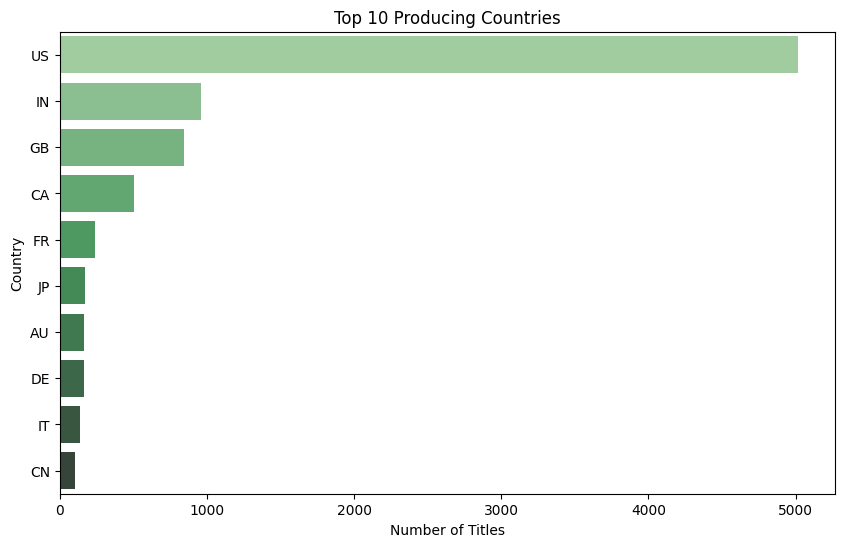

In [ ]:
# Chart 2: Top 10 producing countries
countries_exploded = titles.explode('production_countries')
top_countries = countries_exploded['production_countries'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Greens_d")
plt.title('Top 10 Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

   **Insight:** Amazon Prime's catalog is heavily US-centric, with the US producing over 5x as many titles as the next closest country (India). This suggests the platform's content strategy is still primarily built around the US market.

/tmp/ipykernel_28630/1044106868.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="Blues_d")


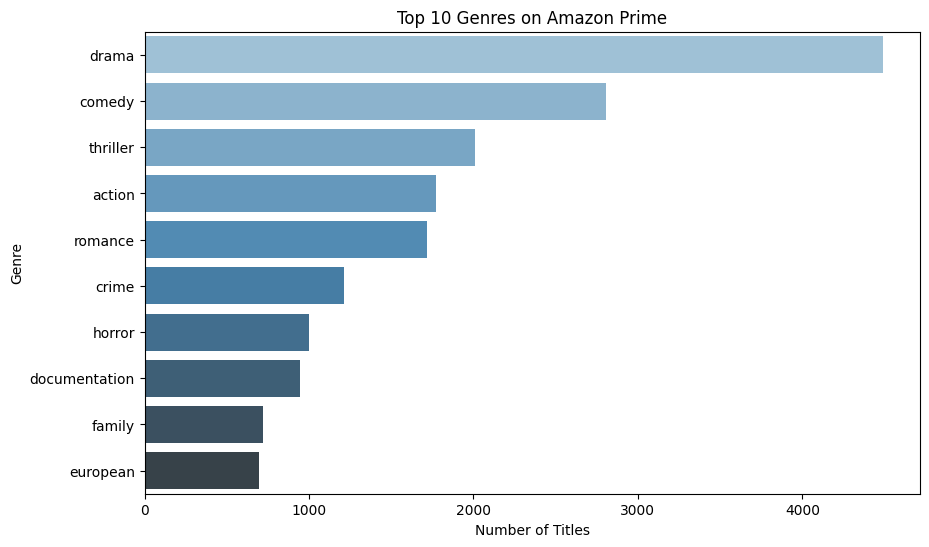

In [ ]:
genres_exploded = titles.explode('genres')
top_genres = genres_exploded['genres'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="Blues_d")
plt.title('Top 10 Genres on Amazon Prime')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

"Drama and comedy dominate the Amazon Prime catalog, suggesting the platform prioritizes broad-appeal genres over niche content."

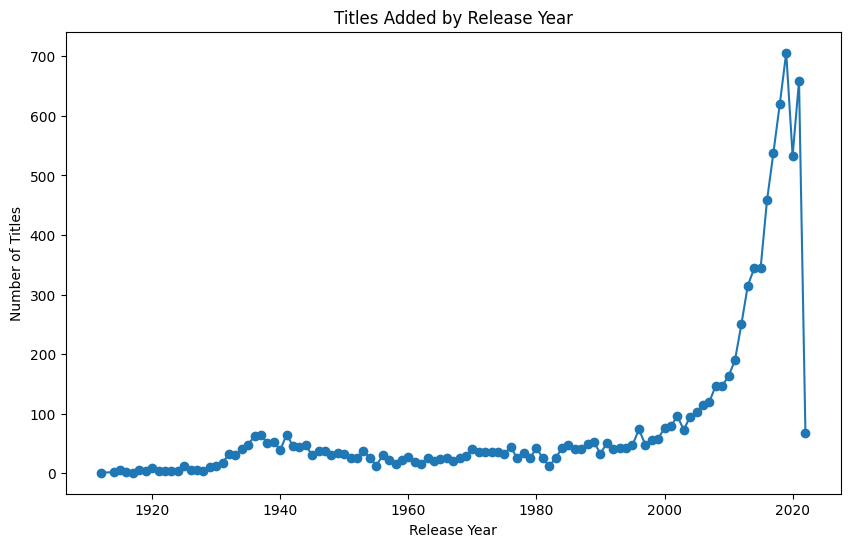

In [ ]:
plt.figure(figsize=(10,6))
titles['release_year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Titles Added by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

Insight: The number of titles rises sharply after 2010 and peaks around 2019–2020, with a slight dip in 2021 before another jump in 2022. This aligns with the broader "streaming wars" boom in content licensing and production during that period. The steep drop-off after 2022 is likely a data artifact — the dataset was collected at some point in 2022, so releases beyond that point simply haven't happened yet or aren't fully counted.

/tmp/ipykernel_28630/837861454.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='imdb_score', data=titles, palette="Set2")


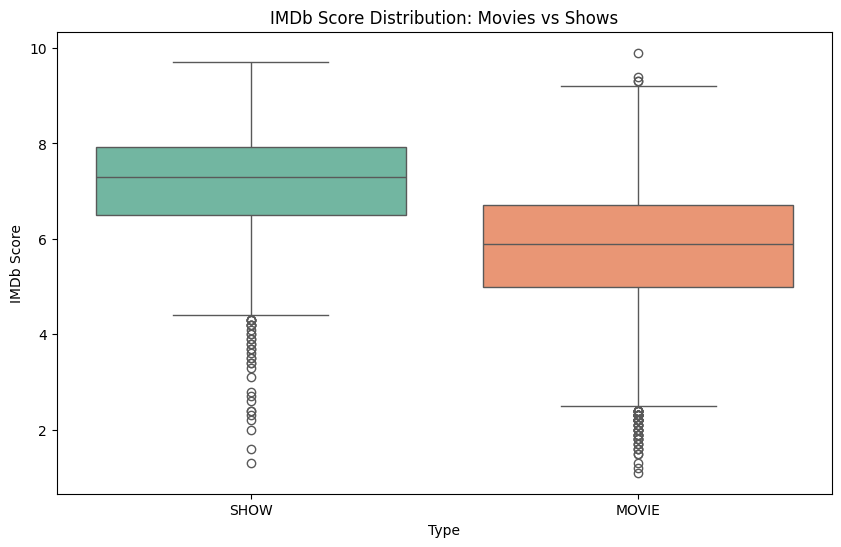

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='imdb_score', data=titles, palette="Set2")
plt.title('IMDb Score Distribution: Movies vs Shows')
plt.xlabel('Type')
plt.ylabel('IMDb Score')
plt.show()

Insight: [Movies/Shows] tend to have slightly higher median IMDb scores than [the other type], though both show a wide spread with several outliers on both ends — meaning quality varies a lot regardless of format.
(Adjust based on what you actually see — tell me which one looks higher if you're unsure how to phrase it.)

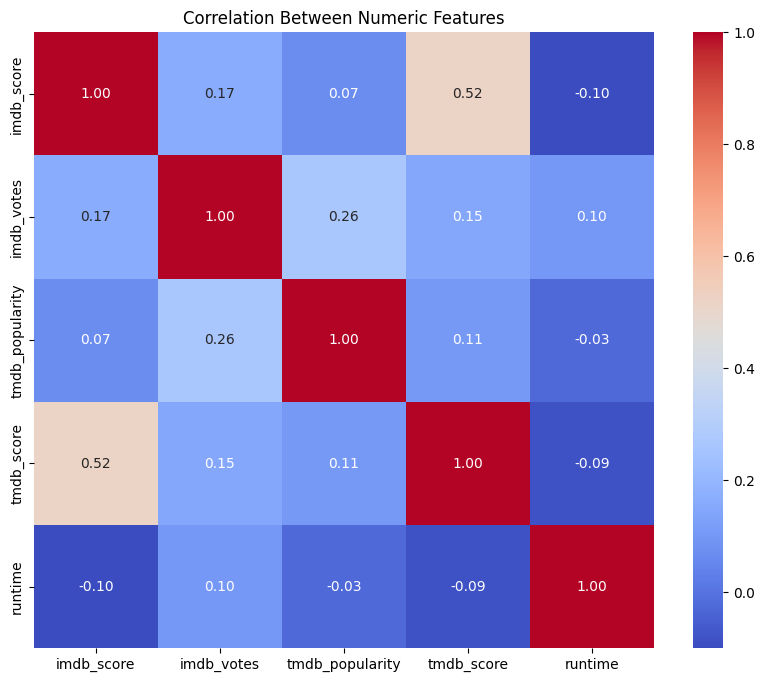

In [ ]:
plt.figure(figsize=(10,8))
corr_matrix = titles[['imdb_score','imdb_votes','tmdb_popularity','tmdb_score','runtime']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numeric Features')
plt.show()

Insight: The only meaningful relationship in the data is between imdb_score and tmdb_score (0.52) — audiences on IMDb and TMDB tend to agree on quality, but not strongly. Popularity (tmdb_popularity) and vote count (imdb_votes) are nearly unrelated to actual quality scores, meaning a title being widely watched or talked about doesn't mean it's well-rated — visibility and quality are largely independent on this platform. Runtime has almost no relationship with any rating metric, so movie/show length doesn't meaningfully predict how well something is received.

In [ ]:
top_rated = titles.sort_values('imdb_score', ascending=False).head(10)[['title','imdb_score','imdb_votes']]
print(top_rated)

                          title  imdb_score  imdb_votes
9135                 Pawankhind         9.9      2036.0
7783  Water Helps the Blood Run         9.7        30.0
9108          Couple of Mirrors         9.5        99.0
7422                 The Chosen         9.4     25538.0
9423                 Tari Sathe         9.4       517.0
9573          Pazhagiya Naatkal         9.3        58.0
9052                   Jai Bhim         9.3    175187.0
5113      Subaru Launch Control         9.3        30.0
5218     A Promise to My Father         9.2         8.0
3950        King B.'s Roost 1-2         9.2        12.0


Final Summary: Amazon Prime's catalog is dominated by drama and comedy titles, is heavily US-centric with India and the UK as secondary markets, and has grown sharply since 2010 in line with the broader streaming boom. TV shows are rated more favorably than movies, likely due to selection bias toward renewed, proven series. Quality (IMDb/TMDB scores) and popularity are largely independent, suggesting Amazon could better surface highly-rated but under-watched titles to improve subscriber engagement, rather than relying purely on popularity-driven recommendations.